### 1. Exponential Growth (Level 1: Future Value)
* **Programming Task:** Write a script to compare **Linear Growth** (Simple Interest: $I = Prt$) vs. **Exponential Growth** (Compound Interest: $A = P(1+r)^t$).
* **Logic:** * Initialize a starting principal.
    * Use a `for` loop or NumPy array to calculate values over 30 years.
    * **Visualization:** Plot both on one graph to see where the exponential curve "decouples" from the linear line.

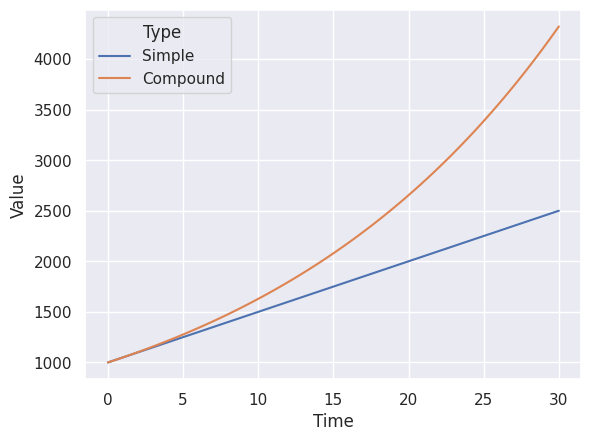

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Parameters
p, r, years = 1000, 0.05, 30
t = np.linspace(0, years, 100)

# 2. Mathematical Logic (Vectorized)
simple = p * (1 + r * t)
compound = p * (1 + r)**t

# 3. Simplify for Seaborn: Put data into a DataFrame
df = pd.DataFrame({
    'Time': np.tile(t, 2),
    'Value': np.concatenate([simple, compound]),
    'Type': ['Simple'] * len(t) + ['Compound'] * len(t)
})

# 4. Plotting with sns
sns.set_theme(style="darkgrid") # Sets minimalist background
sns.lineplot(data=df, x='Time', y='Value', hue='Type')

plt.show()


#### Step-by-Step Logic of the `df` Block

#### 1. `'Time': np.tile(t, 2)`
*   **The Problem:** You have two different growth curves, but they both happen over the same 10-year window.
*   **The Logic:** `np.tile(t, 2)` takes your time array ($0 \dots 10$) and repeats it.
*   **Result:** You get a single column that goes $0 \dots 10$, then starts over at $0 \dots 10$ again. The first half is for the Simple points, the second half is for the Compound points.

#### 2. `'Value': np.concatenate([simple, compound])`
*   **The Logic:** This "glues" the 100 results of your simple interest calculation to the 100 results of your compound interest calculation.
*   **Result:** A single vertical column of 200 numbers.


#### 3. `'Type': ['Simple'] * len(t) + ['Compound'] * len(t)`
*   **The Logic:** This is the most critical part for Seaborn. It creates the "ID tags."
*   **`['Simple'] * len(t)`**: Creates a list containing the word "Simple" 100 times.
*   **`['Compound'] * len(t)`**: Creates a list containing the word "Compound" 100 times.
*   **The `+`**: Merges them into one list of 200 strings.
*   **Result:** Now, every "Value" has a "Type" next to it. 

### Why `len(t)` is better than `100`
If you decide you want a smoother curve and change your `linspace` to **500** points:
*   `np.tile` will automatically repeat the 500 points.
*   `np.concatenate` will glue the two 500-point arrays (1000 total).
*   `len(t)` will evaluate to 500, creating 500 "Simple" tags and 500 "Compound" tags.

----

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

p, r, years = 1000, 0.05, 30

# Generate 100 points for a smooth curve
t = np.linspace(0, years, 100)

simple = p * (1 + r * t)
compound = p * (1 + r)**t

# Plotting directly without melting
sns.lineplot(x=t, y=simple, label='Simple')
sns.lineplot(x=t, y=compound, label='Compound')

plt.show()